<a href="https://colab.research.google.com/github/KartikTotlani/FODS/blob/main/FODS_Assn6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv('heart (1).csv', delimiter=',')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
# Data Cleaning

# a. Checking for missing values
print("\nMissing Values Count by Column:")
print(df.isnull().sum())


Missing Values Count by Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [9]:
# Fill missing numeric values with the median of each column
# Convert relevant columns to numeric before filling missing values
for column in df.select_dtypes(include=['object']).columns:
    try:
        df[column] = pd.to_numeric(df[column])
    except ValueError:
        # Handle columns that cannot be converted to numeric (e.g., categorical)
        pass

df.fillna(df.median(), inplace=True)

In [11]:
# b. Convert categorical columns (e.g., 'sex', 'cp', 'fbs', 'exang', 'slope', 'ca', 'thal') to category type for optimized memory usage
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in categorical_columns:
    df[col] = df[col].astype('category')

In [12]:
# c. Remove duplicates if any
df.drop_duplicates(inplace=True)

In [13]:
# d. Correct erroneous entries
# Identify outliers in critical columns (like 'age', 'trestbps', 'chol', 'thalach') using thresholds

# Example: Removing outliers beyond plausible ranges (for 'age' and 'chol' as examples)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
df = df[(df['chol'] >= 100) & (df['chol'] <= 500)]  # Adjust as per dataset knowledge


In [14]:
print("\nCleaned Dataset Overview:")
print(df.head())


Cleaned Dataset Overview:
   age sex cp  trestbps  chol fbs restecg  thalach exang  oldpeak slope ca  \
0   52   1  0       125   212   0       1      168     0      1.0     2  2   
1   53   1  0       140   203   1       0      155     1      3.1     0  0   
2   70   1  0       145   174   0       1      125     1      2.6     0  0   
3   61   1  0       148   203   0       1      161     0      0.0     2  1   
4   62   0  0       138   294   1       1      106     0      1.9     1  3   

  thal target  
0    3      0  
1    3      0  
2    3      0  
3    3      0  
4    2      0  


In [15]:
# Summary statistics after cleaning
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              age    trestbps        chol     thalach     oldpeak
count  301.000000  301.000000  301.000000  301.000000  301.000000
mean    54.378738  131.657807  245.445183  149.534884    1.041196
std      9.033793   17.566422   48.479011   22.933737    1.162940
min     29.000000   94.000000  126.000000   71.000000    0.000000
25%     48.000000  120.000000  211.000000  133.000000    0.000000
50%     55.000000  130.000000  240.000000  152.000000    0.800000
75%     61.000000  140.000000  274.000000  166.000000    1.600000
max     77.000000  200.000000  417.000000  202.000000    6.200000


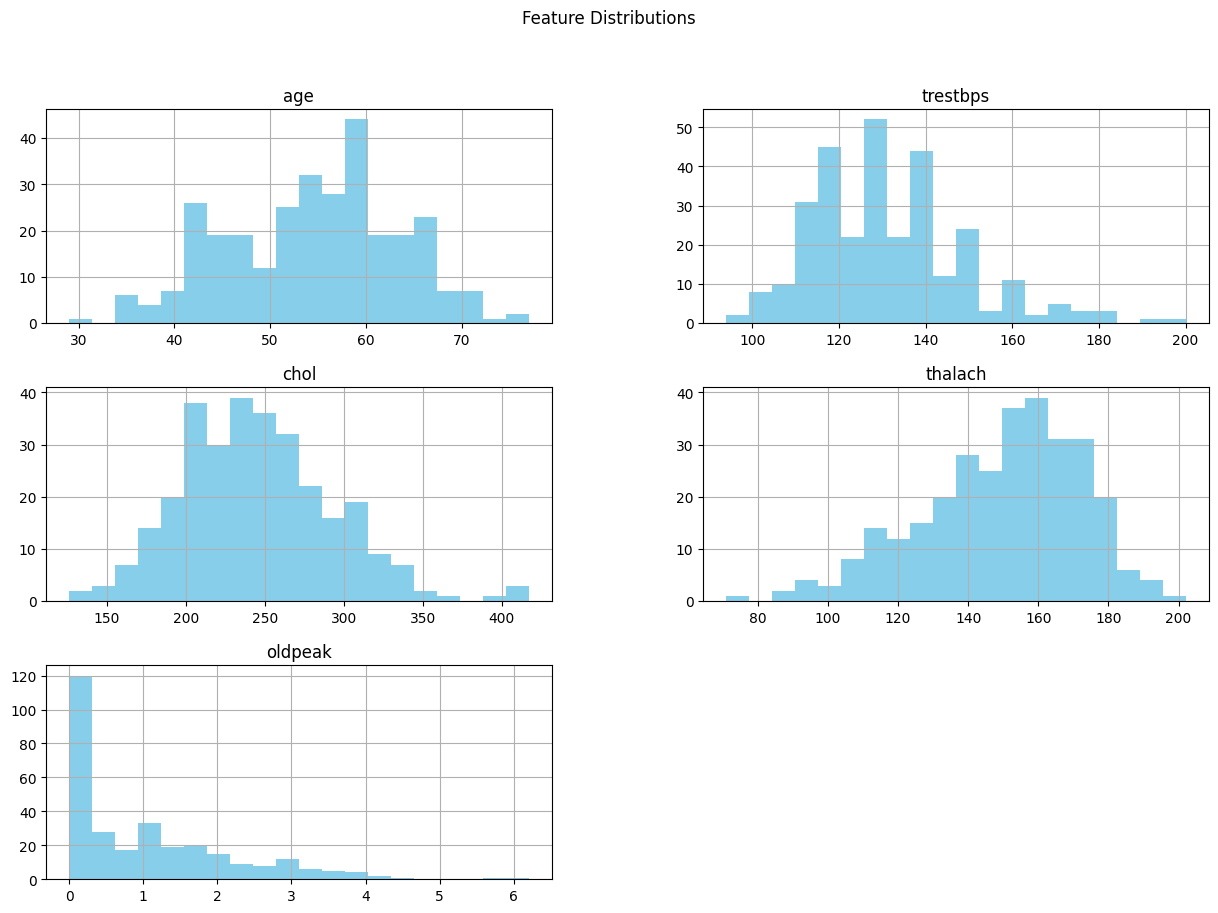

In [16]:
# 1. Histograms for each feature
df.hist(bins=20, figsize=(15, 10), color='skyblue')
plt.suptitle("Feature Distributions")
plt.show()


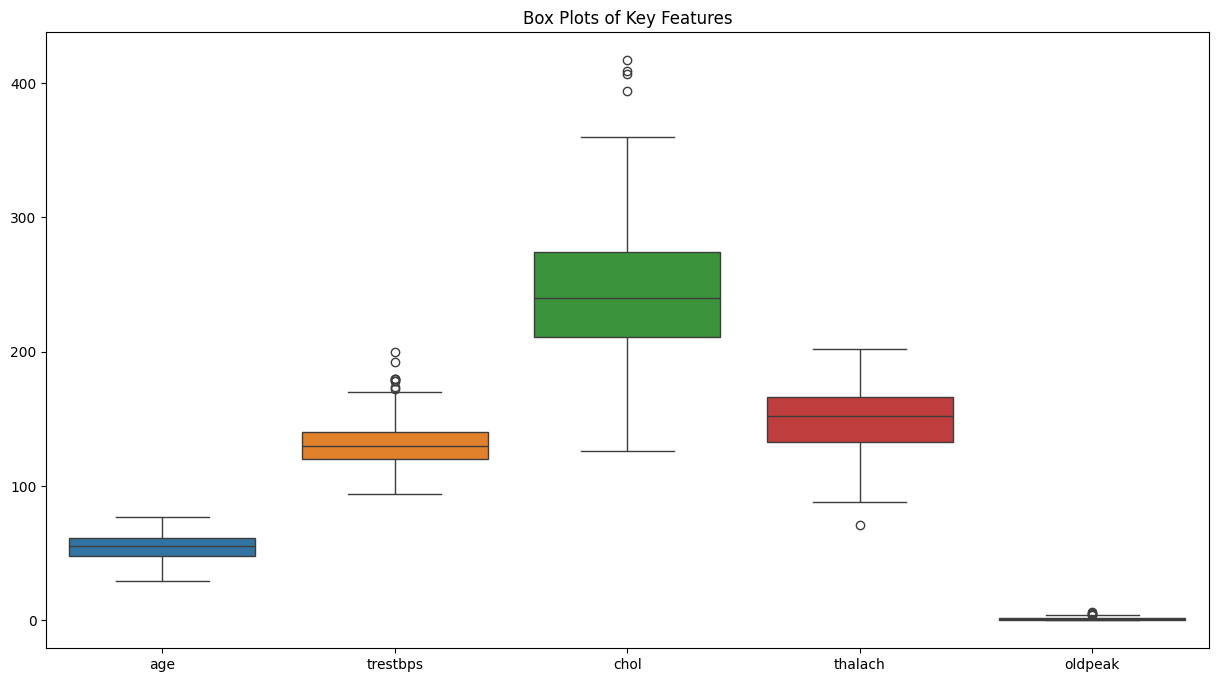

In [17]:
# 2. Box plots for key features to visualize outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[["age", "trestbps", "chol", "thalach", "oldpeak"]])
plt.title("Box Plots of Key Features")
plt.show()

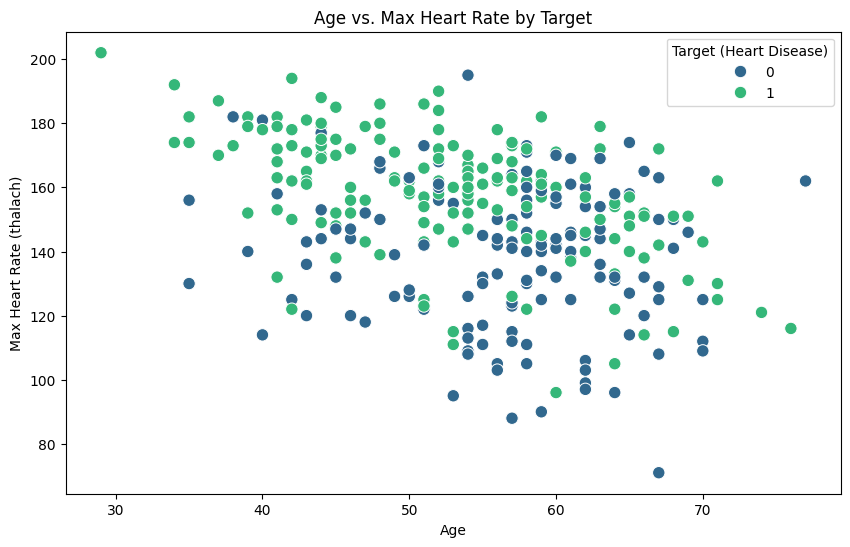

In [18]:
# 3. Scatter plot to analyze age vs. maximum heart rate (thalach)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette='viridis', edgecolor='w', s=80)
plt.title("Age vs. Max Heart Rate by Target")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend(title="Target (Heart Disease)")
plt.show()

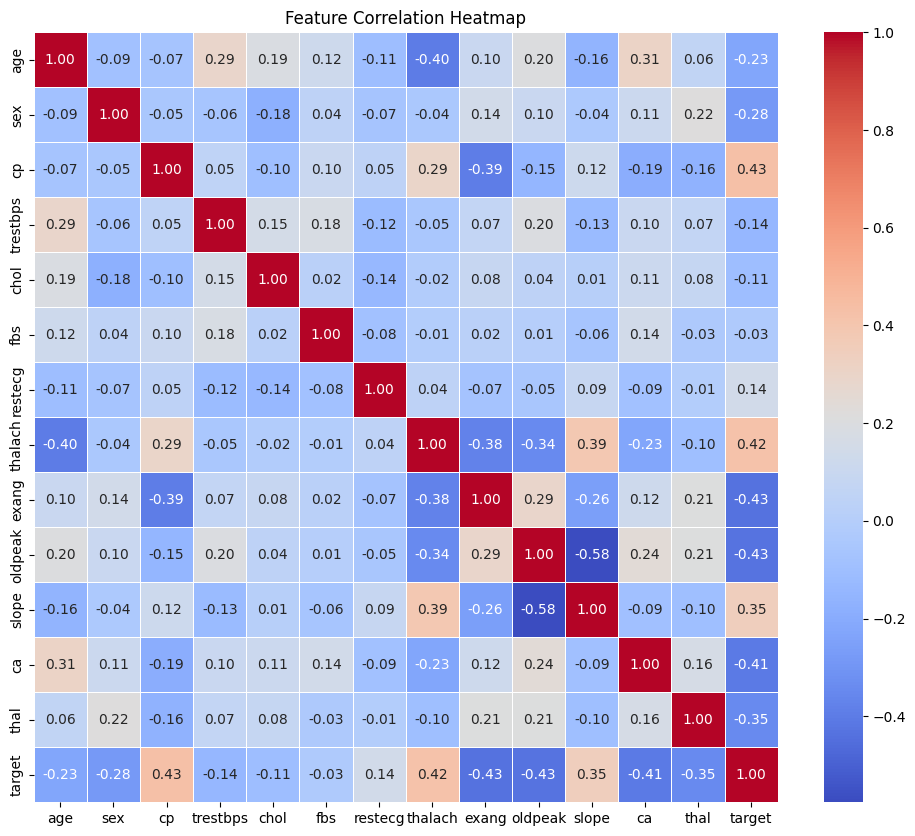

In [19]:
# 4. Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

<ipython-input-20-7d0a27306d6b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


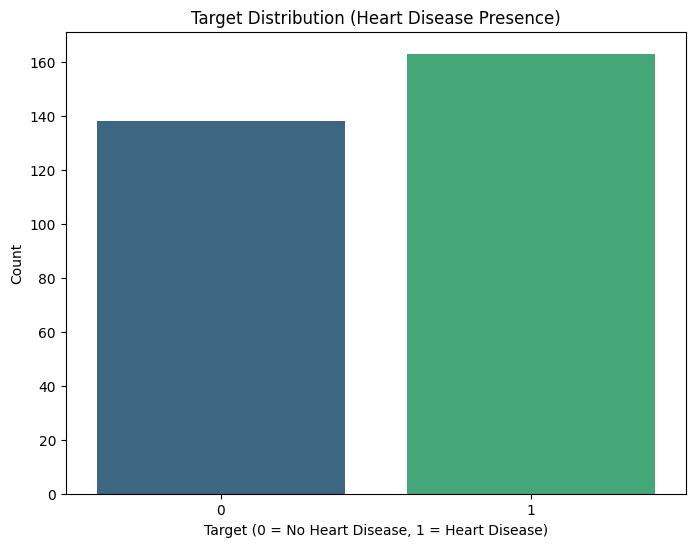

In [20]:
# 5. Count plot for the target variable to understand class balance
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='viridis')
plt.title("Target Distribution (Heart Disease Presence)")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Count")
plt.show()

In [22]:

# Select only numerical features for Z-score scaling
numerical_features = df.select_dtypes(include=['number']).columns
df_ZScaled = pd.DataFrame((df[numerical_features] - df[numerical_features].mean()) / df[numerical_features].std(),
                         columns=numerical_features,
                         index=df.index)

# Concatenate scaled numerical features with original categorical features
categorical_features = df.select_dtypes(exclude=['number']).columns
df_ZScaled = pd.concat([df_ZScaled, df[categorical_features]], axis=1)

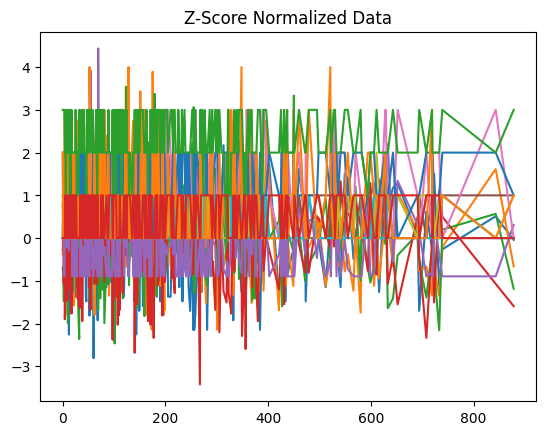

In [23]:
plt.plot(df_ZScaled)
plt.title('Z-Score Normalized Data')
plt.show()